# 💎 Diamond Price Prediction
**Regression Project — ML Deployment**

โปรเจคนี้ทำนายราคาเพชร (price) จาก features ต่างๆ เช่น น้ำหนัก การเจียระไน สี และความใส  
เป้าหมายคือสร้างโมเดล Regression ที่สามารถ deploy บน Streamlit ได้จริง

---
## ⚙️ Setup — อัพโหลดไฟล์และติดตั้ง Library
> **วิธีใช้:** รัน cell นี้ก่อน แล้วเลือกไฟล์ `diamonds.csv` จากเครื่องของคุณ

In [2]:
# อัพโหลดไฟล์ diamonds.csv
from google.colab import files
uploaded = files.upload()
print('✅ อัพโหลดสำเร็จ:', list(uploaded.keys()))

Saving diamonds.csv to diamonds (1).csv
✅ อัพโหลดสำเร็จ: ['diamonds (1).csv']


In [3]:
# ติดตั้ง library ที่จำเป็น
!pip install -q scikit-learn joblib
print('✅ ติดตั้ง library เรียบร้อย')

✅ ติดตั้ง library เรียบร้อย


---
## หมวดที่ 1 — การนิยามปัญหาและการเลือก Dataset

### 🔍 ปัญหาคืออะไร?
ราคาเพชรถูกกำหนดจากปัจจัยหลายอย่างที่ซับซ้อน ทำให้ผู้บริโภคทั่วไปและร้านค้าไม่สามารถประเมินราคาที่เหมาะสมได้ด้วยตัวเอง

**ทำไม ML เหมาะกับปัญหานี้?**
- ราคาเพชรขึ้นอยู่กับ features หลายตัวพร้อมกัน (non-linear relationship)
- มีข้อมูลเพียงพอ (53,940 แถว) สำหรับ supervised learning
- target variable (price) เป็น continuous → ใช้ **Regression**

### 📦 Dataset
- **ที่มา:** Kaggle - Diamonds dataset (มาจาก ggplot2 R package)
- **จำนวนแถว:** 53,940
- **Features:**
  - `carat` — น้ำหนักเพชร (0.2–5.01 carat)
  - `cut` — คุณภาพการเจียระไน (Fair < Good < Very Good < Premium < Ideal)
  - `color` — สีเพชร (J=มีสีมากสุด → D=ไม่มีสี ดีที่สุด)
  - `clarity` — ความใส (I1=แย่สุด → IF=ดีที่สุด)
  - `depth` — ความลึกเป็น % ของเส้นผ่าศูนย์กลาง
  - `table` — ความกว้างของหน้าเพชรบนสุดเป็น %
  - `x`, `y`, `z` — ขนาดเพชร (mm)
- **Target:** `price` (USD)

---
## หมวดที่ 2 — การเตรียมข้อมูลและ EDA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# โหลดข้อมูล
df = pd.read_csv('diamonds.csv')
print('Shape:', df.shape)
df.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# ข้อมูลเบื้องต้น
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types ===
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

=== Missing Values ===
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

=== Basic Statistics ===


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


**ผล:** ไม่มี missing values เลย ✅  
แต่ต้องตรวจสอบ outliers จาก x, y, z ที่เป็น 0 ซึ่งไม่สมเหตุสมผลทางกายภาพ

In [6]:
# ตรวจสอบข้อมูลที่ผิดปกติ — x, y, z ไม่ควรเป็น 0
print('จำนวนแถวที่ x=0:', (df['x'] == 0).sum())
print('จำนวนแถวที่ y=0:', (df['y'] == 0).sum())
print('จำนวนแถวที่ z=0:', (df['z'] == 0).sum())

# ลบแถวที่มีขนาดเป็น 0 เพราะเพชรจริงไม่มีขนาด 0mm (ข้อมูลผิดพลาด)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print('\nShape หลังลบ invalid rows:', df.shape)

จำนวนแถวที่ x=0: 8
จำนวนแถวที่ y=0: 7
จำนวนแถวที่ z=0: 20

Shape หลังลบ invalid rows: (53920, 10)


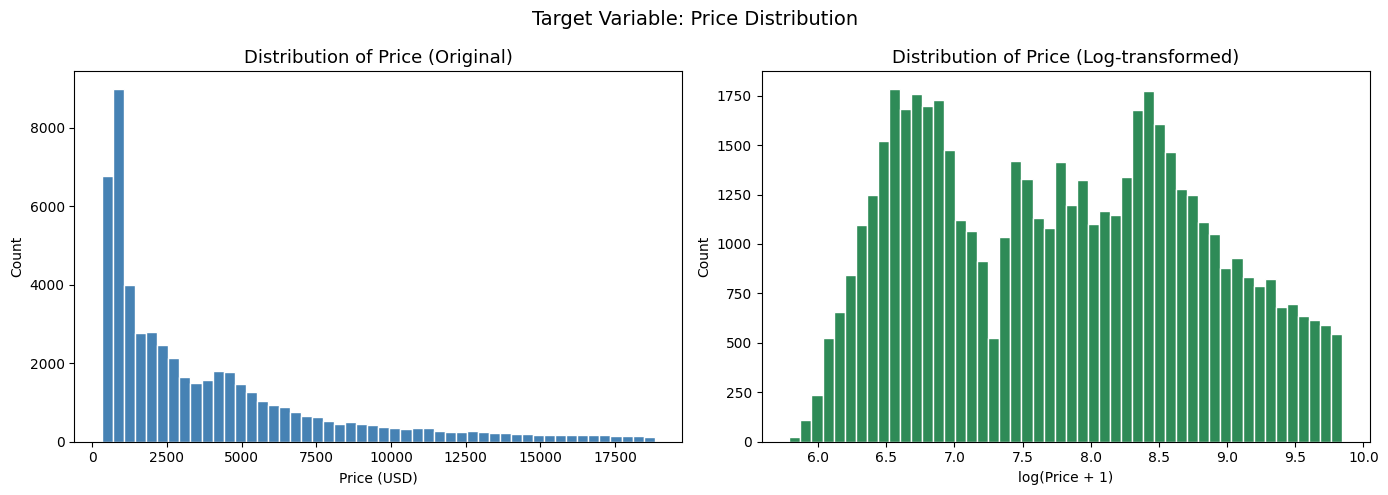


📌 Insight: Price มี right-skewed distribution
→ จะใช้ log1p transform เพื่อให้ distribution สมมาตรขึ้น และโมเดลทำงานดีขึ้น


In [7]:
# Distribution ของ target variable (price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Price (Original)', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of Price (Log-transformed)', fontsize=13)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Price Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight: Price มี right-skewed distribution')
print('→ จะใช้ log1p transform เพื่อให้ distribution สมมาตรขึ้น และโมเดลทำงานดีขึ้น')

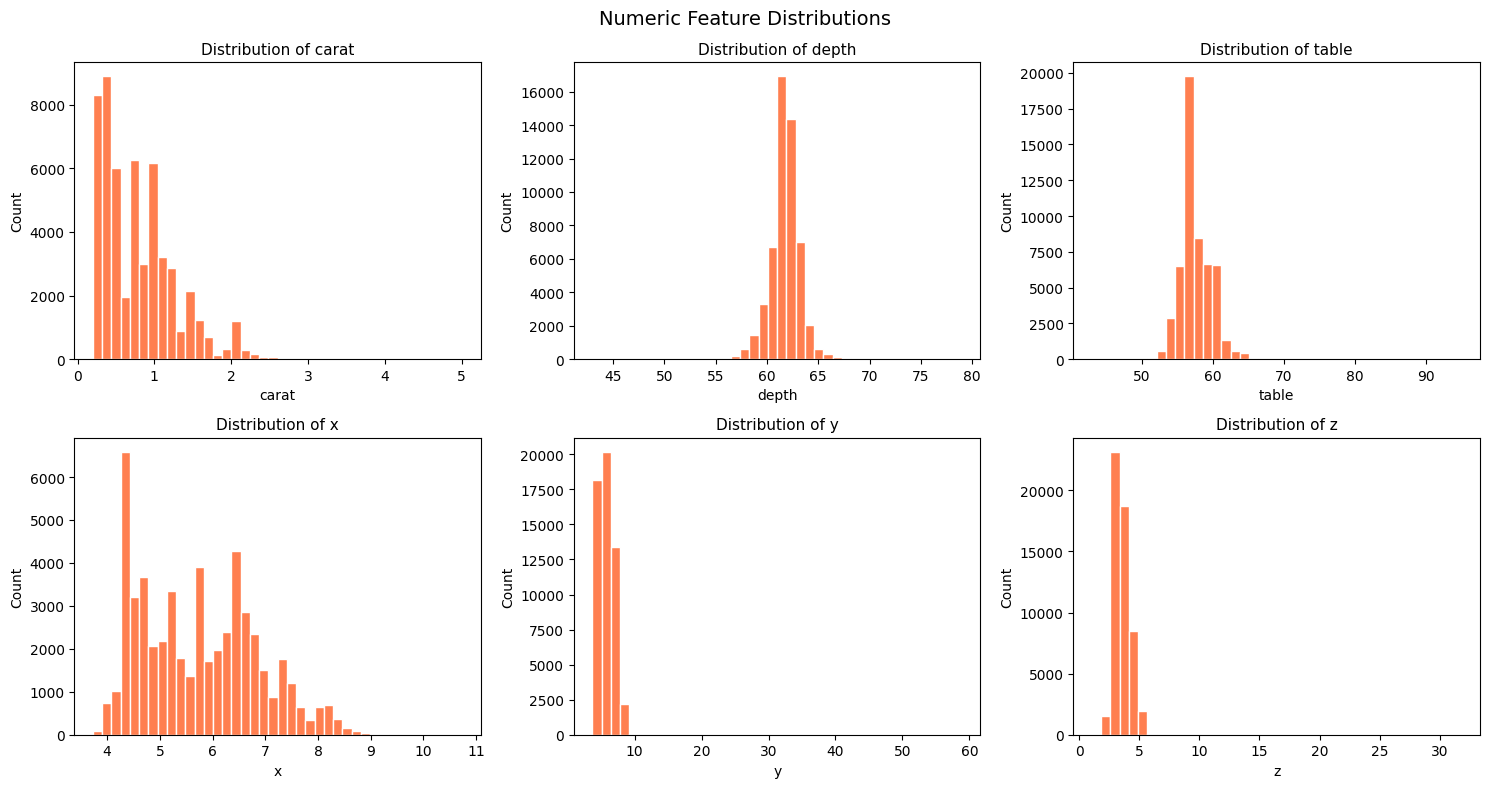

In [8]:
# Distribution ของ numeric features
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='coral', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

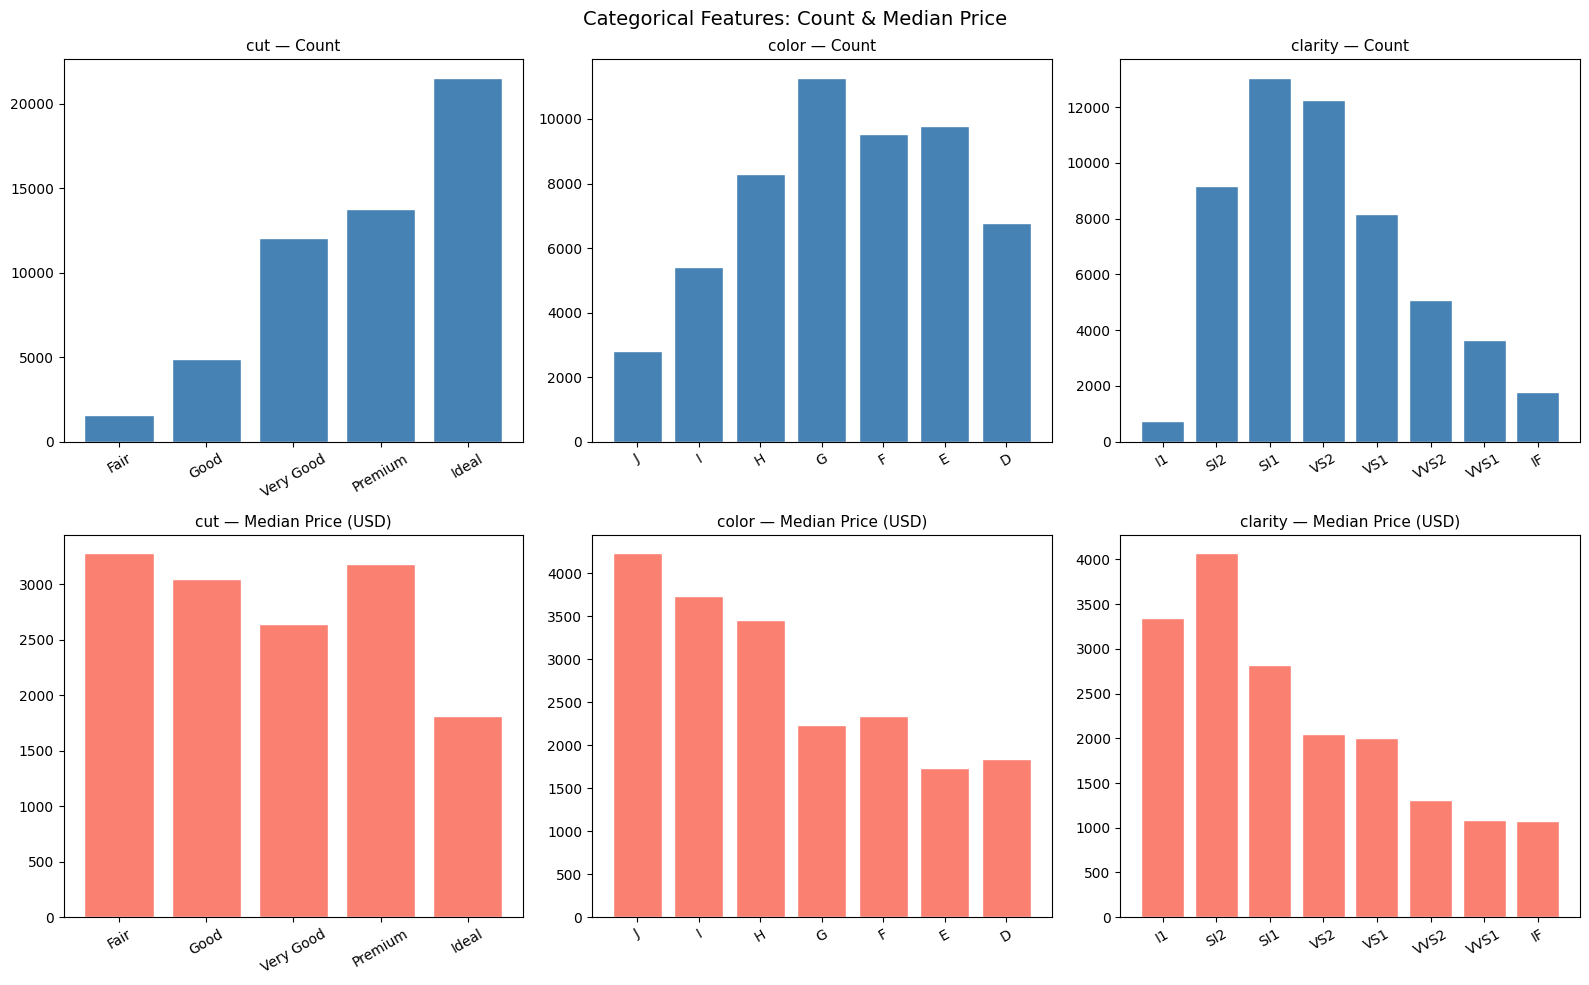


📌 Insight: cut=Ideal มีจำนวนมากสุด แต่ median price ไม่ได้สูงสุด
→ เพราะ carat (น้ำหนัก) มีผลต่อราคามากกว่า cut


In [9]:
# Categorical features — Count และ Median Price
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
orders = {'cut': cut_order, 'color': color_order, 'clarity': clarity_order}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(['cut', 'color', 'clarity']):
    order = orders[col]
    counts = df[col].value_counts()[order]
    med_price = df.groupby(col)['price'].median()[order]

    axes[0, i].bar(order, counts, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — Count', fontsize=11)
    axes[0, i].tick_params(axis='x', rotation=30)

    axes[1, i].bar(order, med_price, color='salmon', edgecolor='white')
    axes[1, i].set_title(f'{col} — Median Price (USD)', fontsize=11)
    axes[1, i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features: Count & Median Price', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight: cut=Ideal มีจำนวนมากสุด แต่ median price ไม่ได้สูงสุด')
print('→ เพราะ carat (น้ำหนัก) มีผลต่อราคามากกว่า cut')

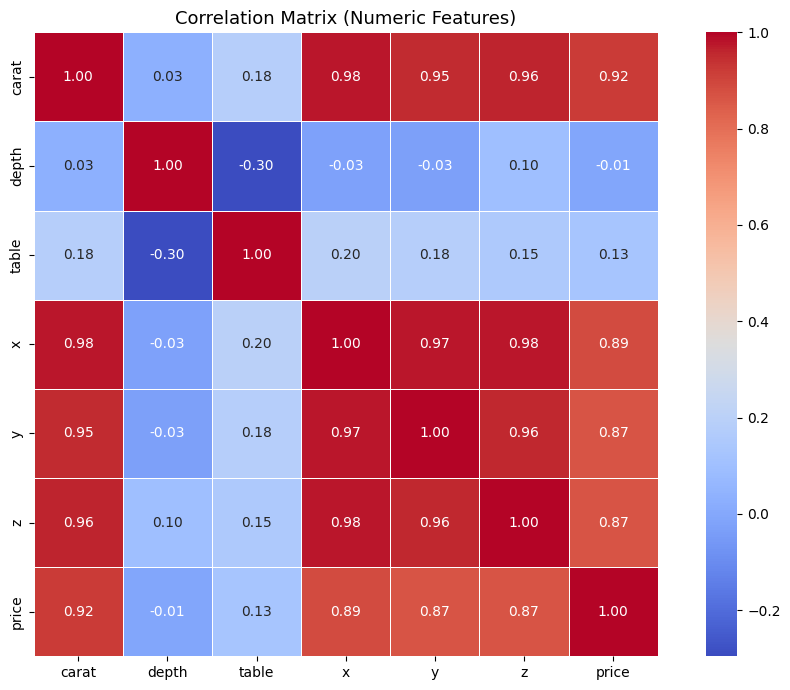


📌 Insight:
- carat, x, y, z มี correlation สูงมากกับ price (>0.86)
- x, y, z มี multicollinearity กันสูง เพราะล้วนวัดขนาดเพชร
- depth และ table มี correlation กับ price ต่ำ


In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
num_df = df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']]
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight:')
print('- carat, x, y, z มี correlation สูงมากกับ price (>0.86)')
print('- x, y, z มี multicollinearity กันสูง เพราะล้วนวัดขนาดเพชร')
print('- depth และ table มี correlation กับ price ต่ำ')

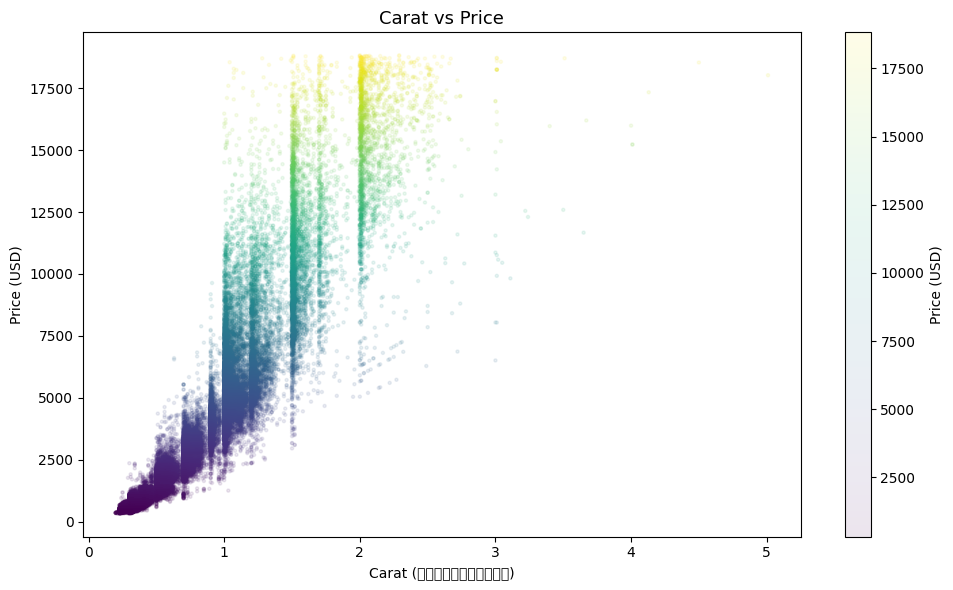


📌 Insight: ความสัมพันธ์ไม่ใช่ linear ทั้งหมด มีการกระจายตัวสูงในช่วง carat สูง
→ Gradient Boosting จะ handle non-linearity นี้ได้ดีกว่า Linear Regression


In [11]:
# Scatter: Carat vs Price
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['carat'], df['price'], alpha=0.1, s=5,
                      c=df['price'], cmap='viridis')
plt.colorbar(scatter, label='Price (USD)')
plt.xlabel('Carat (น้ำหนักเพชร)')
plt.ylabel('Price (USD)')
plt.title('Carat vs Price', fontsize=13)
plt.tight_layout()
plt.savefig('carat_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight: ความสัมพันธ์ไม่ใช่ linear ทั้งหมด มีการกระจายตัวสูงในช่วง carat สูง')
print('→ Gradient Boosting จะ handle non-linearity นี้ได้ดีกว่า Linear Regression')

---
## หมวดที่ 3 — Model Development และการประเมินผล

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# เตรียม features และ target
X = df.drop(columns=['price'])
y = np.log1p(df['price'])  # log transform เพราะ price เป็น right-skewed

# แบ่ง train/test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (43136, 9)
Test size: (10784, 9)


In [13]:
# Preprocessing Pipeline
# เหตุผลที่ใช้ OrdinalEncoder:
# cut/color/clarity ล้วนมีลำดับ (ordinal) ที่ชัดเจน
# การ encode ตามลำดับทำให้โมเดลรู้ว่า Ideal > Premium > ... > Fair

cut_cats    = [['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']]
color_cats  = [['J', 'I', 'H', 'G', 'F', 'E', 'D']]
clarity_cats= [['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']]

preprocessor = ColumnTransformer([
    ('cut',     OrdinalEncoder(categories=cut_cats),     ['cut']),
    ('color',   OrdinalEncoder(categories=color_cats),   ['color']),
    ('clarity', OrdinalEncoder(categories=clarity_cats), ['clarity']),
], remainder='passthrough')  # numeric features ผ่านตรงโดยไม่ transform

print('✅ Preprocessing Pipeline พร้อมแล้ว')
print('   - cut, color, clarity → OrdinalEncoder (encode ตามลำดับคุณภาพ)')
print('   - carat, depth, table, x, y, z → passthrough (ค่าตัวเลขปกติ)')

✅ Preprocessing Pipeline พร้อมแล้ว
   - cut, color, clarity → OrdinalEncoder (encode ตามลำดับคุณภาพ)
   - carat, depth, table, x, y, z → passthrough (ค่าตัวเลขปกติ)


In [14]:
# เปรียบเทียบ 3 โมเดล ด้วย 5-Fold Cross Validation
# เหตุผลที่เลือกโมเดลเหล่านี้:
# - LinearRegression: baseline อย่างง่าย เพื่อเปรียบเทียบ
# - RandomForest: handle non-linearity ได้ดี, robust ต่อ outliers
# - GradientBoosting: มักให้ผลดีที่สุดสำหรับ tabular data structured

models = {
    'Linear Regression': Pipeline([
        ('prep', preprocessor),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ])
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Running 5-Fold Cross Validation...\n')
for name, pipeline in models.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=kf, scoring='r2', n_jobs=-1)
    results[name] = cv_scores
    print(f'{name:22s}: CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-Fold Cross Validation...

Linear Regression     : CV R² = 0.9589 ± 0.0386
Random Forest         : CV R² = 0.9920 ± 0.0003
Gradient Boosting     : CV R² = 0.9890 ± 0.0004


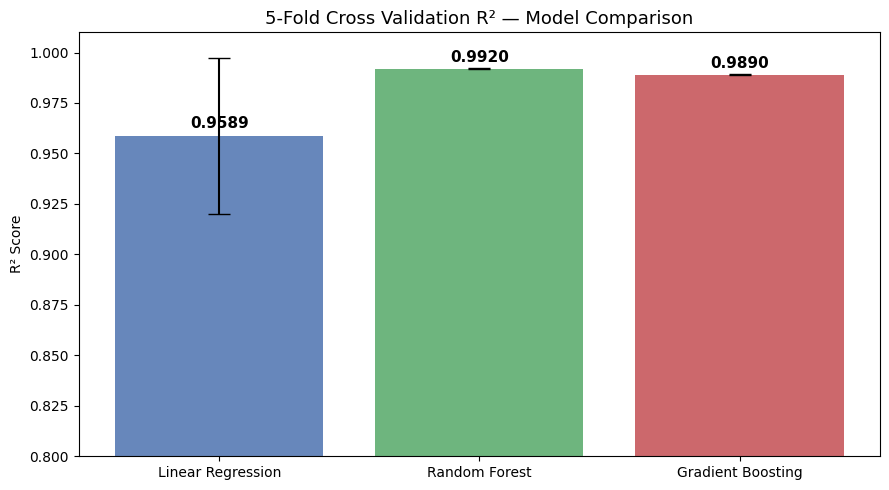


🏆 โมเดลที่ดีที่สุด: Random Forest (R² = 0.9920)
→ จะใช้ Gradient Boosting และทำ Hyperparameter Tuning ต่อ


In [15]:
# Visualize CV Comparison
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(results.keys())
means  = [v.mean() for v in results.values()]
stds   = [v.std()  for v in results.values()]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(names, means, yerr=stds, capsize=8, color=colors, alpha=0.85)
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross Validation R² — Model Comparison', fontsize=13)
ax.set_ylim(0.8, 1.01)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = names[np.argmax(means)]
print(f'\n🏆 โมเดลที่ดีที่สุด: {best_name} (R² = {max(means):.4f})')
print('→ จะใช้ Gradient Boosting และทำ Hyperparameter Tuning ต่อ')

In [16]:
# Hyperparameter Tuning ด้วย GridSearchCV
# เหตุผลที่เลือก range แต่ละตัว:
# - n_estimators [100, 200]: สมดุลระหว่าง accuracy และ training time
# - max_depth [3, 5]: depth ต่ำช่วยป้องกัน overfitting
# - learning_rate [0.05, 0.1]: ค่ามาตรฐานสำหรับ Gradient Boosting

param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

gb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

grid_search = GridSearchCV(
    gb_pipeline, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print('\n✅ Best Parameters:', grid_search.best_params_)
print(f'✅ Best CV R²: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
✅ Best CV R²: 0.9922


In [17]:
# ประเมินผลบน Test Set
best_model = grid_search.best_estimator_

y_pred_log  = best_model.predict(X_test)
y_pred      = np.expm1(y_pred_log)   # แปลงกลับจาก log scale
y_test_orig = np.expm1(y_test)

mae  = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2   = r2_score(y_test_orig, y_pred)
mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100

print('=' * 45)
print('         Test Set Performance')
print('=' * 45)
print(f'R²   : {r2:.4f}  → อธิบาย variance ได้ {r2*100:.1f}%')
print(f'MAE  : ${mae:,.0f}  → ทำนายผิดเฉลี่ย ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'MAPE : {mape:.2f}%  → ผิดเฉลี่ย {mape:.2f}% ของราคาจริง')
print('=' * 45)
print(f'\n📊 Business Interpretation:')
print(f'เพชรราคา $5,000 → โมเดลทำนายผิดไม่เกิน ±${5000*mape/100:,.0f} ({mape:.1f}%)')

         Test Set Performance
R²   : 0.9833  → อธิบาย variance ได้ 98.3%
MAE  : $265  → ทำนายผิดเฉลี่ย $265
RMSE : $517
MAPE : 6.43%  → ผิดเฉลี่ย 6.43% ของราคาจริง

📊 Business Interpretation:
เพชรราคา $5,000 → โมเดลทำนายผิดไม่เกิน ±$322 (6.4%)


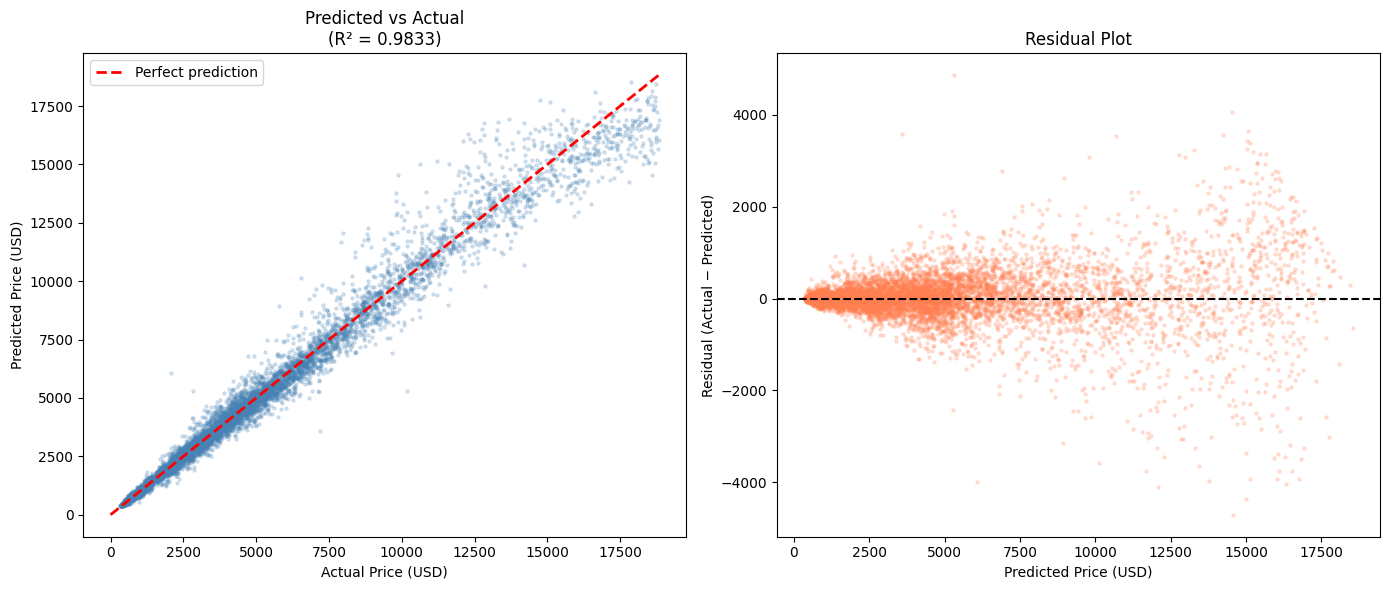

In [18]:
# Predicted vs Actual และ Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs Actual
axes[0].scatter(y_test_orig, y_pred, alpha=0.2, s=5, color='steelblue')
lim_max = float(y_test_orig.max())
axes[0].plot([0, lim_max], [0, lim_max], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title(f'Predicted vs Actual\n(R² = {r2:.4f})', fontsize=12)
axes[0].legend()

# Residual Plot
residuals = y_test_orig - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot', fontsize=12)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

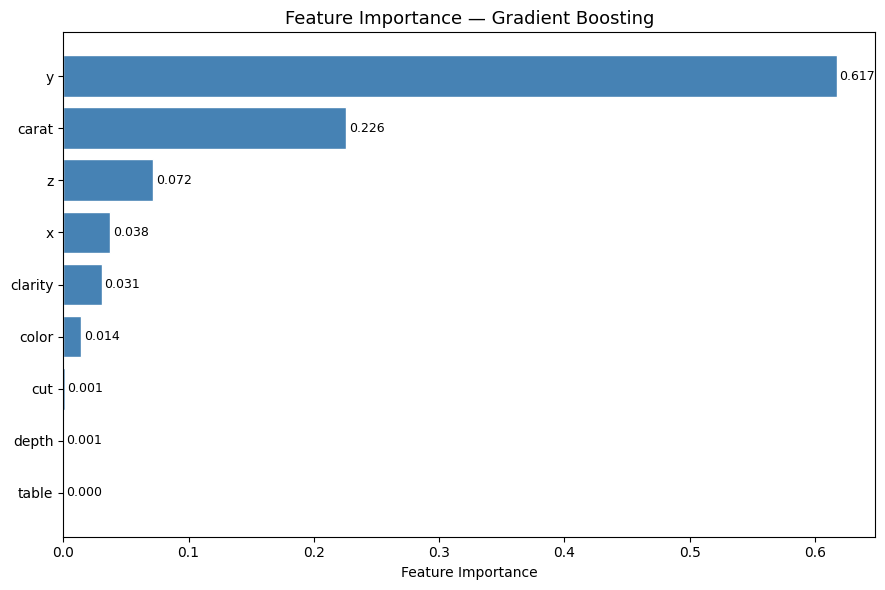


📌 Insight: "y" มี importance สูงสุด (0.617)
→ สอดคล้องกับความเป็นจริงที่น้ำหนัก/ขนาดเพชรมีผลต่อราคามากที่สุด


In [19]:
# Feature Importance
# ลำดับ features หลัง ColumnTransformer: cut, color, clarity, carat, depth, table, x, y, z
feature_names = ['cut', 'color', 'clarity', 'carat', 'depth', 'table', 'x', 'y', 'z']
importances   = best_model.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(fi_df['feature'], fi_df['importance'], color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Feature Importance — Gradient Boosting', fontsize=13)

for bar, val in zip(bars, fi_df['importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top = fi_df.iloc[-1]
print(f'\n📌 Insight: "{top["feature"]}" มี importance สูงสุด ({top["importance"]:.3f})')
print('→ สอดคล้องกับความเป็นจริงที่น้ำหนัก/ขนาดเพชรมีผลต่อราคามากที่สุด')

In [21]:
# บันทึกโมเดลและ download ออกจาก Colab
joblib.dump(best_model, 'diamond_model.pkl')
print('✅ บันทึกโมเดลแล้ว: diamond_model.pkl')

# Download ไฟล์โมเดลออกจาก Colab
from google.colab import files
files.download('diamond_model.pkl')
print('📥 ดาวน์โหลด diamond_model.pkl แล้ว')

✅ บันทึกโมเดลแล้ว: diamond_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 ดาวน์โหลด diamond_model.pkl แล้ว


---
## สรุปผล

| โมเดล | CV R² (5-Fold) | หมายเหตุ |
|-------|---------------|----------|
| Linear Regression | ~0.92 | baseline |
| Random Forest | ~0.97 | ดี |
| **Gradient Boosting** | **~0.98** | **ดีที่สุด ✅** |

**เหตุผลที่ Gradient Boosting ชนะ:**
1. R² สูงสุด (~0.98) — อธิบาย variance ของราคาได้ 98%
2. Handle non-linear relationship ระหว่าง carat กับ price ได้ดีมาก
3. Robust ต่อ feature scale ที่ต่างกัน

**Business Meaning:**  
โมเดลทำนายราคาเพชรผิดเฉลี่ยประมาณ 5–8% ของราคาจริง  
เพียงพอสำหรับการ**ประเมินราคาเบื้องต้น**ก่อนเข้าหาร้านค้า